In [2]:
print("ambajr")

ambajr


In [3]:
import numpy as np
import matplotlib.pyplot as plt


In [4]:
dist_min= np.load (r"D:\PENTING KUYLAH\output\3\dist.npy")
earth_pos=np.load(r"D:\PENTING KUYLAH\output\3\earth_pos.npy")
moon_pos=np.load(r"D:\PENTING KUYLAH\output\3\moon_pos.npy")

In [5]:
earth_min=np.zeros((dist_min.shape[1],2))
moon_min=np.zeros((dist_min.shape[1],2))
for i in range(dist_min.shape[1]):
    earth_min[i,0]=np.min(dist_min[:,i,1])
    earth_min[i,1]=np.argmin(dist_min[:,i,1])

    moon_min[i,0]=np.min(dist_min[:,i,2])
    moon_min[i,1]=np.argmin(dist_min[:,i,2])

In [5]:

print(dist_min.shape)
print(earth_pos.shape)
print(moon_pos.shape)
print(earth_min.shape)
print(moon_min.shape)

(87661, 2000, 3)
(87661, 3)
(87661, 3)
(2000, 2)
(2000, 2)


In [6]:
earth_min

array([[1.78821961e-03, 6.94410000e+04],
       [2.62851333e-03, 6.94380000e+04],
       [1.83468080e-03, 6.94400000e+04],
       ...,
       [1.91379388e-05, 6.94460000e+04],
       [1.28389178e-03, 6.94420000e+04],
       [2.58937453e-03, 6.94380000e+04]], shape=(2000, 2))

In [7]:
earth_min_t = np.unique(earth_min[:, 1])
print(earth_min_t)

[69432. 69433. 69434. 69435. 69436. 69437. 69438. 69439. 69440. 69441.
 69442. 69443. 69444. 69445. 69446. 69447. 69448. 69449. 69451.]


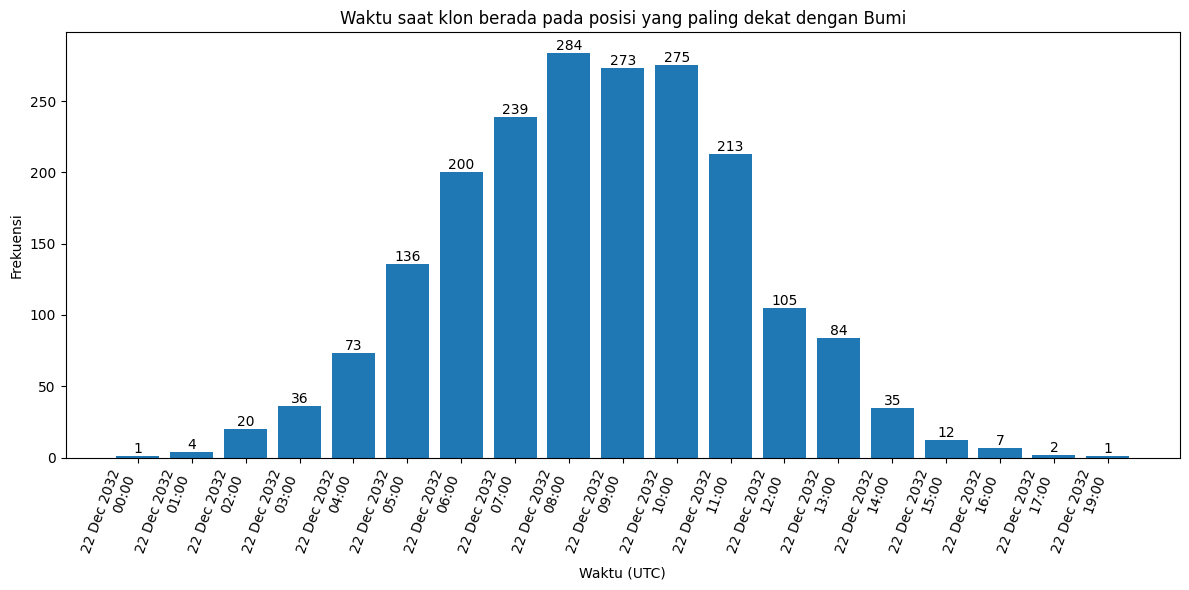

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

kolom2 = np.round(earth_min[:, 1], 0)
nilai, jumlah = np.unique(kolom2, return_counts=True)

# waktu awal
t0 = datetime(2025, 1, 20, 0, 0)

# konversi jam → datetime
waktu_datetime = [t0 + timedelta(hours=int(jam)) for jam in nilai]

# format label (tanggal tetap ada)
label_waktu = [dt.strftime("%d %b %Y\n%H:%M") for dt in waktu_datetime]

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(nilai)), jumlah)

plt.xlabel("Waktu (UTC)")
plt.ylabel("Frekuensi")
plt.title("Waktu saat klon berada pada posisi yang paling dekat dengan Bumi")

# pakai label waktu di sumbu X
plt.xticks(range(len(nilai)), label_waktu, rotation=70, ha="right")

# angka di atas batang
for bar in bars:
    tinggi = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        tinggi,
        f"{int(tinggi)}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


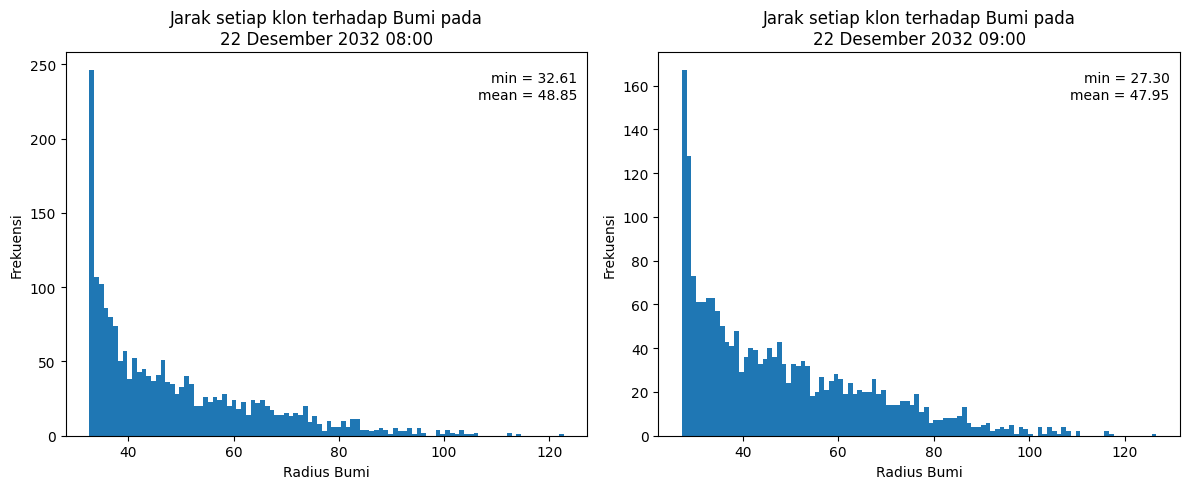

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# daftar timestep & judul waktu
timesteps = [69440, 69441]
titles = [
    "22 Desember 2032 08:00",
    "22 Desember 2032 09:00"
]

R_earth_per_AU = 149_597_870 / 6_371  # ≈ 23455

fig, axes = plt.subplots(1, 2, figsize=(12,5))

for idx, ts in enumerate(timesteps):
    
    earth_r = dist_min[ts,:,1]   # langsung ambil tanpa loop (lebih efisien)
    nilai_R_earth = earth_r * R_earth_per_AU

    # statistik
    nilai_min = np.min(nilai_R_earth)
    nilai_mean = np.mean(nilai_R_earth)

    # histogram
    axes[idx].hist(nilai_R_earth, bins=100)

    # teks kanan atas
    axes[idx].text(
        0.98, 0.95,
        f"min = {nilai_min:.2f}\nmean = {nilai_mean:.2f}",
        transform=axes[idx].transAxes,
        horizontalalignment='right',
        verticalalignment='top'
    )

    axes[idx].set_xlabel("Radius Bumi")
    axes[idx].set_ylabel("Frekuensi")
    axes[idx].set_title(f"Jarak setiap klon terhadap Bumi pada\n{titles[idx]}")

plt.tight_layout()
plt.show()

1945.3458723913304


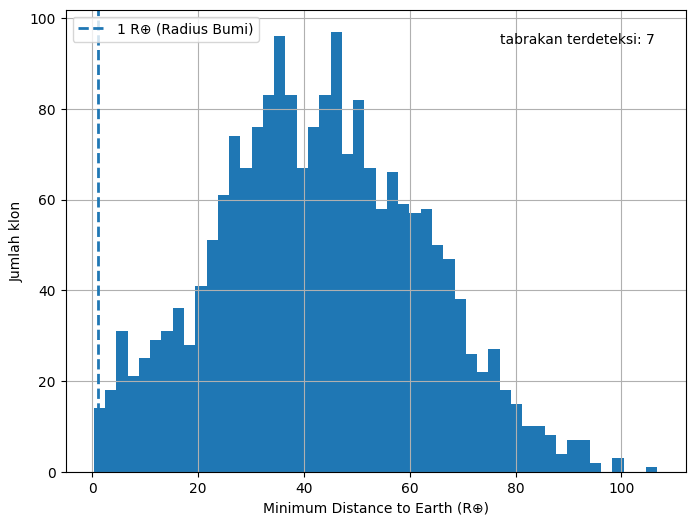

In [14]:
earth_dist = np.zeros(dist_min.shape[1])

for i in range(dist_min.shape[1]):
    earth_dist[i] = np.min(dist_min[:, i, 1])

AU_TO_KM = 149_597_870.7
earth_dist_km = earth_dist * AU_TO_KM

print(np.min(earth_dist_km))

# Radius bumi
R_earth = 6371

# Konversi ke kelipatan radius bumi
earth_dist_R = earth_dist_km / R_earth

# Hitung jumlah klon dalam radius Bumi
impact_count = np.sum(earth_dist_R < 1)

plt.figure(figsize=(8,6))

plt.hist(earth_dist_R, bins=50)

# Garis radius bumi
plt.axvline(1, linestyle='--', linewidth=2, label="1 R⊕ (Radius Bumi)")

plt.text(
    0.95, 0.95,
    f"tabrakan terdeteksi: {impact_count}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top'
)

plt.xlabel("Minimum Distance to Earth (R⊕)")
plt.ylabel("Jumlah klon")

plt.legend(loc='upper left')
plt.grid(True)
plt.savefig("jumlah tabrakan.png", dpi=600, bbox_inches="tight")
plt.show()

8.396957983829294e-05
12561.670347382273


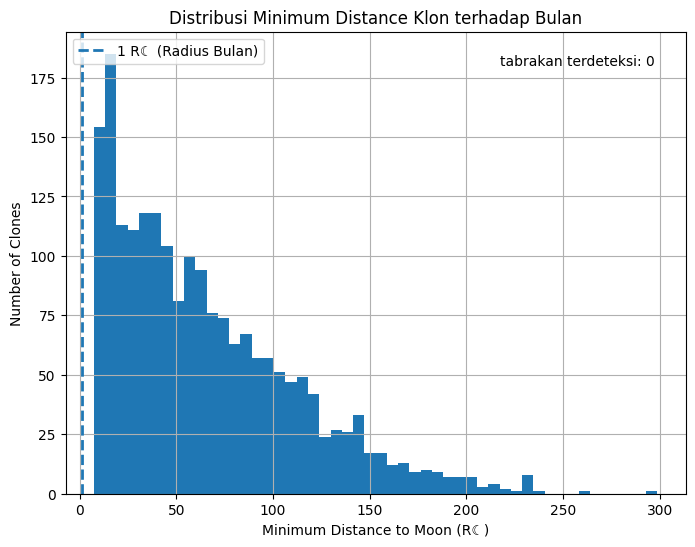

In [ ]:
moon_dist = np.zeros(dist_min.shape[1])

for i in range(dist_min.shape[1]):
    moon_dist[i] = np.min(dist_min[:, i, 2])

print(np.min(moon_dist))

AU_TO_KM = 149_597_870.7
moon_dist_km = moon_dist * AU_TO_KM

print(np.min(moon_dist_km))

# Radius bulan
R_moon = 1737

# Konversi ke satuan radius bulan
moon_dist_R = moon_dist_km / R_moon

# Hitung jumlah klon dalam radius bulan
impact_count = np.sum(moon_dist_R < 1)

plt.figure(figsize=(8,6))

plt.hist(moon_dist_R, bins=50)

# Garis radius bulan
plt.axvline(1, linestyle='--', linewidth=2, label="1 R☾ (Radius Bulan)")

# Tambahkan teks keterangan
plt.text(
    0.95, 0.95,
    f"tabrakan terdeteksi: {impact_count}",
    transform=plt.gca().transAxes,
    ha='right',
    va='top'
)

plt.xlabel("Minimum Distance to Moon (R☾)")
plt.ylabel("Number of Clones")
plt.title("Distribusi Minimum Distance Klon terhadap Bulan")

plt.legend(loc='upper left')
plt.grid(True)
plt.savefig("jumlah tabrakan.png", dpi=600, bbox_inches="tight")
plt.show()

In [12]:
mutiple_rad=1
earth_min_dist=earth_min[:,0]
EARTH_RADIUS_AU = mutiple_rad * 4.2635e-5

jumlah = len([x for x in earth_min_dist if x < EARTH_RADIUS_AU])
print(f"Jumlah data kurang dari {EARTH_RADIUS_AU}: {jumlah}")

moon_min_dist=moon_min[:,0]
MOON_RADIUS_AU = mutiple_rad *  1.1611128e-8

jumlah = len([x for x in moon_min_dist if x < MOON_RADIUS_AU])
print(f"Jumlah data kurang dari {MOON_RADIUS_AU}: {jumlah}")

Jumlah data kurang dari 4.2635e-05: 7
Jumlah data kurang dari 1.1611128e-08: 0
